In [13]:
import torch
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import os

# --- CONFIGURATION ---
# These parameters MUST match the ones used in the training/generation scripts.
SEQ_LEN = 12      # Input history length
PRED_LEN = 3     # Output forecast horizon
DATA_PATH = '../../ICL4DT/data/time_series_datasets/ETTm2.csv'
HTI_DATA_DIR = 'hti_data'

# The quantiles of the expert models you want to visualize
QUANTILES_TO_LOAD = [0.01, 0.1, 0.25, 0.5, 0.75,0.9, 0.99]

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')

In [14]:
print("Loading original dataset...")
df = pd.read_csv(DATA_PATH)
data = df['OT'].values.astype(float)

print(f"Full dataset shape: {data.shape}")

# Recreate the exact train/val/test split to fit the scaler correctly
train_split_idx = int(len(data) * 0.7)
val_split_idx = int(len(data) * 0.98)

# Isolate the original, unscaled test data for ground truth comparison
original_test_data = data[val_split_idx:]

# Fit the scaler ONLY on the training data to prevent data leakage
print("Fitting MinMaxScaler on the training data portion...")
scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(data[:train_split_idx].reshape(-1, 1))

Loading original dataset...
Full dataset shape: (69680,)
Fitting MinMaxScaler on the training data portion...


,feature_range,"(-1, ...)"
,copy,True
,clip,False


In [15]:
hti_datasets = {}
all_forecasts_unscaled = {}

print("Loading HTI datasets and unscaling forecasts...")

for q in QUANTILES_TO_LOAD:
    # Construct filename (e.g., hti_data_q05.pt)
    filename = f"hti_data_q{str(q).replace('.', '')}.pt"
    path = os.path.join(HTI_DATA_DIR, filename)
    
    try:
        # Load the entire [history, forecast] tensor
        hti_datasets[q] = torch.load(path)
        print(f" -> Loaded '{filename}' with shape: {hti_datasets[q].shape}")

        # Extract the scaled forecasts (the last PRED_LEN columns)
        forecasts_scaled = hti_datasets[q][:, SEQ_LEN:].numpy()
        
        # Inverse transform the forecasts to their original scale (degrees Celsius)
        forecasts_unscaled = scaler.inverse_transform(forecasts_scaled)
        all_forecasts_unscaled[q] = forecasts_unscaled
        
    except FileNotFoundError:
        print(f" -> WARNING: Could not find file {path}. Skipping.")

print("\nForecasts are now unscaled and ready for plotting.")

Loading HTI datasets and unscaling forecasts...
 -> Loaded 'hti_data_q001.pt' with shape: torch.Size([1380, 15])
 -> Loaded 'hti_data_q01.pt' with shape: torch.Size([1380, 15])
 -> Loaded 'hti_data_q025.pt' with shape: torch.Size([1380, 15])
 -> Loaded 'hti_data_q05.pt' with shape: torch.Size([1380, 15])
 -> Loaded 'hti_data_q075.pt' with shape: torch.Size([1380, 15])
 -> Loaded 'hti_data_q09.pt' with shape: torch.Size([1380, 15])
 -> Loaded 'hti_data_q099.pt' with shape: torch.Size([1380, 15])

Forecasts are now unscaled and ready for plotting.


In [16]:
def plot_forecast(sample_idx, original_test_data, all_forecasts, seq_len, pred_len):
    """
    Plots the ground truth history, ground truth future, and multiple quantile forecasts
    for a single sample from the test set.
    
    Args:
        sample_idx (int): The index of the sample to plot (from the HTI dataset).
        original_test_data (np.array): The original, unscaled test portion of the time series.
        all_forecasts (dict): A dictionary mapping quantiles to their unscaled forecast arrays.
        seq_len (int): The length of the input history.
        pred_len (int): The length of the forecast horizon.
    """
    # --- Get Ground Truth Data ---
    # The sample_idx corresponds to the start of the window in the test set
    gt_history = original_test_data[sample_idx : sample_idx + seq_len]
    gt_future = original_test_data[sample_idx + seq_len : sample_idx + seq_len + pred_len]
    
    # --- Create X-axis indices for plotting ---
    history_indices = np.arange(0, seq_len)
    future_indices = np.arange(seq_len, seq_len + pred_len)

    # --- Plotting ---
    plt.figure(figsize=(18, 8))
    
    # Plot history and future
    plt.plot(history_indices, gt_history, color='black', label='Ground Truth History')
    plt.plot(future_indices, gt_future, color='blue', label='Ground Truth Future', marker='o', linestyle='--')
    
    # Plot each quantile forecast
    for quantile, forecasts in all_forecasts.items():
        forecast_to_plot = forecasts[sample_idx]
        plt.plot(future_indices, forecast_to_plot, label=f'Forecast (τ={quantile})', marker='x', alpha=0.8)
        
    plt.title(f'Forecast vs. Ground Truth for Test Sample #{sample_idx}', fontsize=16)
    plt.xlabel('Time Steps', fontsize=12)
    plt.ylabel('Oil Temperature (OT)', fontsize=12)
    plt.legend(fontsize=10)
    plt.axvline(x=seq_len-1, color='gray', linestyle='--', linewidth=2, label='Forecast Start')
    plt.show()

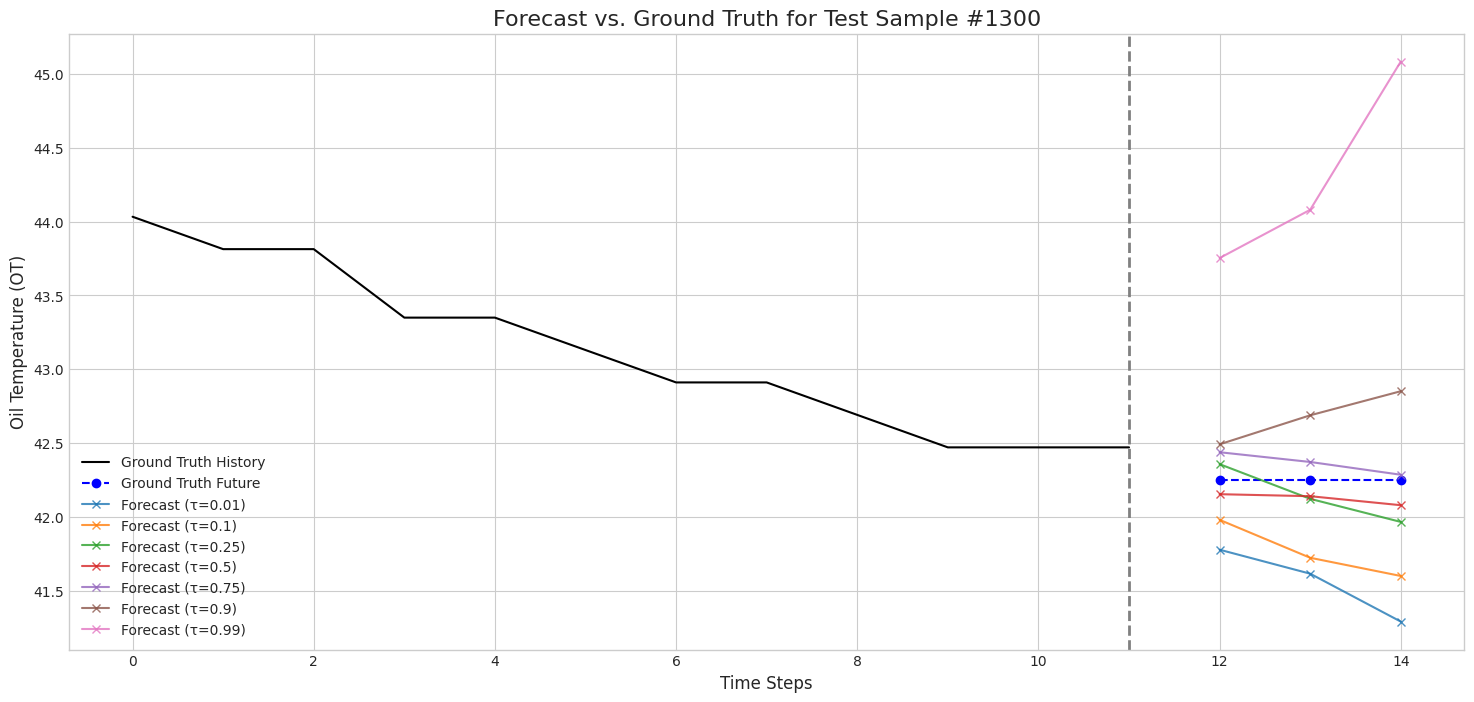

In [34]:
SAMPLE_TO_PLOT = 1300

if all_forecasts_unscaled:
    plot_forecast(
        sample_idx=SAMPLE_TO_PLOT,
        original_test_data=original_test_data,
        all_forecasts=all_forecasts_unscaled,
        seq_len=SEQ_LEN,
        pred_len=PRED_LEN
    )
else:
    print("No forecasts were loaded. Please check the file paths and quantiles.")